In [1]:
import pydelfi.priors as priors
import pydelfi.ndes as ndes
import pydelfi.delfi as delfi

import gc

/global/homes/j/joshuaw/.conda/envs/delfi/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import tensorflow.compat.v1 as tf1
tf1.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [11]:
def inv_scale_params(theta):
    hi = np.array([0.5, 1.0, -0.33])
    lo = np.array([0.13, 0.0, -1.8])
    theta_ = theta.copy()
    s = 0.6
    theta_[:, 0] = ((theta[:, 0] - (1 - s) * 0.5) * (hi[0] - lo[0]) / s) + lo[0]
    theta_[:, 1] += 0.25
    theta_[:, 2] = ((theta[:, 2] - (1 - s) * 0.5) * (hi[2] - lo[2]) / s) + lo[2]
    return theta_

In [3]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt
# import getdist
import random
import emcee as mc
# from getdist import plots, MCSamples
import scipy.interpolate as interpolate
import time
from scipy.interpolate import UnivariateSpline
import tensorflow as tf
import pydelfi.score as score
# tf.logging.set_verbosity(tf.logging.ERROR)
%matplotlib inline
from scipy.integrate import simps


In [5]:
# Set priors
# lower = np.array([0.16, 0.45,-1.0])
# upper = np.array([0.52, 1.0,-0.33])
lower = np.array([0.16, 0.45,-1.])
upper = np.array([0.52, 1.0,-0.33])
prior = priors.Uniform(lower, upper)

In [13]:
# --load 6D params
data_6D = np.load('formatted_6D_summaries.npz')
params_val_full = data_6D['params_val']
params_LFI_full = data_6D['params_LFI']
params_test_full = data_6D['params_test']

preds_val_full = data_6D['preds_val']
preds_LFI_full = data_6D['preds_LFI']
preds_test_full = data_6D['preds_test']

params_LFI = np.concatenate([params_LFI_full, params_test_full, params_val_full], axis=0)
preds_LFI = np.concatenate([preds_LFI_full, preds_test_full, preds_val_full], axis=0)
params_LFI = inv_scale_params(params_LFI)
print(params_LFI.shape)
print(preds_LFI.shape)

(8484, 3)
(8484, 6)


In [20]:
tf.keras.backend.clear_session()
NDEs = None
gc.collect()

NDEs = [ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=3, n_data=6, n_hiddens=[50,50], n_mades=4, act_fun=tf.tanh, index=0),
        ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=3, n_data=6, n_hiddens=[40,40], n_mades=4, act_fun=tf.tanh, index=1),
        ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=3, n_data=6, n_hiddens=[50,50], n_mades=5, act_fun=tf.tanh, index=2),
        ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=3, n_data=6, n_hiddens=[50,50], n_mades=6, act_fun=tf.tanh, index=3)]
        # ndes.MixtureDensityNetwork(n_parameters=3, n_data=6, n_components=2, n_hidden=[50,50], activations=[tf.tanh, tf.tanh], index=4)]
        # ndes.MixtureDensityNetwork(n_parameters=3, n_data=3, n_components=6, n_hidden=[30,30], activations=[tf.tanh, tf.tanh], index=3)]


In [26]:
DelfiEnsemble = delfi.Delfi(np.array(np.mean(preds_LFI, axis=0), dtype = 'float'), prior, NDEs,
                            param_limits = [lower, upper],
                            param_names = ['\Omega_m', 'S_8', 'w'], 
                            results_dir = 'DELFI_HYBRID_STATS_RUN_PLS_WORK/')

DelfiEnsemble.load_simulations(preds_LFI, params_LFI)
DelfiEnsemble.train_ndes()

2026-04-05 03:48:04.865574: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1618] Found device 0 with properties: 
name: NVIDIA A100-PCIE-40GB major: 8 minor: 0 memoryClockRate(GHz): 1.41
pciBusID: 0000:c3:00.0
2026-04-05 03:48:04.865843: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'libcudart.so.10.0'; dlerror: libcudart.so.10.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /global/common/software/nersc9/darshan/default/lib:/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/math_libs/12.9/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9/extras/CUPTI/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9/extras/Debugger/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9/nvvm/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9/lib64:/opt/cray/pe/papi/7.2.0.2/lib64:/opt/cray/libfabric/1.22.0/lib64
2026-04-05 03:48:04.866023: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynami

Training:  17%|█▋        | 86/500 [01:10<04:07,  1.67it/s, train loss=-7.02, val loss=-6.77]

INFO:tensorflow:Restoring parameters from DELFI_HYBRID_STATS_RUN_PLS_WORK/graph_checkpoint


Training:  26%|██▌       | 128/500 [00:44<00:58,  6.40it/s, train loss=-7.51, val loss=-7.47]

INFO:tensorflow:Restoring parameters from DELFI_HYBRID_STATS_RUN_PLS_WORK/graph_checkpoint


Training:  36%|███▋      | 182/500 [02:50<04:08,  1.28it/s, train loss=-8.43, val loss=-8.4] 

INFO:tensorflow:Restoring parameters from DELFI_HYBRID_STATS_RUN_PLS_WORK/graph_checkpoint


Training:  32%|███▏      | 160/500 [02:59<05:04,  1.12it/s, train loss=-5.47, val loss=-5.57]

INFO:tensorflow:Restoring parameters from DELFI_HYBRID_STATS_RUN_PLS_WORK/graph_checkpoint


Training:  32%|███▏      | 160/500 [03:00<06:22,  1.13s/it, train loss=-5.47, val loss=-5.57]


In [ ]:
def initial_parameters(theta, relative_sigma):
    """
    This is not randomise the initial position of the
    :param theta: list/array of parameter values
    :param relative_sigma: controls variance of random draws
    :return: the theta array but with random shifts
    """
    theta = np.array(theta)
    return np.random.normal(theta, np.abs(theta * relative_sigma))

n_dim3d=3
n_burn3d=1000
n_steps3d = 20000
n_walkers3d = 2 * n_dim3d

theta3d_expected_mean = params_LFI.mean(axis=0)
# theta3d_expected_mean = [0.3, 0.75, 0.5]

theta0_3d = np.array([list(initial_parameters(theta3d_expected_mean, 0.01)) for i in range(n_walkers3d)])




def prior_term3d(theta3d):
    om, S8, w = theta3d.T
    if ((om<lower[0])|(om>upper[0])):
        return  - np.inf
    if ((S8<lower[1])|(S8>upper[1])):
        return  - np.inf
    if ((w<-1.)|(w>-0.3333)):
        return  - np.inf
    else:
        return  - 0.5*(w+1.)*(w+1.)/(0.3333**2.)
    


def prior_term3d_informative(theta3d):
    om, S8, w = theta3d.T
    if ((om<lower[0])|(om>upper[0])):
        return  - np.inf
    if ((S8<lower[1])|(S8>upper[1])):
        return  - np.inf
    if ((w<-1.)|(w>-0.3333)):
        return  - np.inf
    else:
        return  - 0.5*(w+1.)*(w+1.)/(0.3333**2.) - 0.5*((S8-0.78)/0.07)**2. -  0.5*((om-0.32)/0.065)**2.
    
    


def prior_term3d_flat(theta3d):
    om, S8, w = theta3d.T
    if ((om<lower[0])|(om>upper[0])):
        return  - np.inf
    if ((S8<lower[1])|(S8>upper[1])):
        return  - np.inf
    if ((w<-1.)|(w>-0.3333)):
        return  - np.inf
    else:
        return  0.
                
    

def log_posterior3d_temp(theta3d, data):
    a, b, c = theta3d.T
    if ((c<-1.)|(c>-0.3333)):
        return  - np.inf
    # c = w_transform_forward(c)
    return DelfiEnsemble.log_posterior_stacked([a, b, c],data=data)[0][0] + prior_term3d_informative(theta3d)
    # return  prior_term3d_informative(theta3d)
    



In [47]:
rand_inds = []
samples_LFI = []
for i in range(10):
    i_test = np.random.randint(0, len(preds_LFI))
    sampler3d = mc.EnsembleSampler(n_walkers3d, n_dim3d, log_posterior3d_temp,
                                args=(preds_LFI[i_test],))
    _ = sampler3d.run_mcmc(theta0_3d, n_burn3d+n_steps3d)
    samples3d = sampler3d.get_chain()
    samples_LFI.append(samples3d)
    rand_inds.append(i_test)


In [45]:
_ = sampler3d.run_mcmc(theta0_3d, n_burn3d+n_steps3d)

emcee: Exception while calling your likelihood function:
  params: [ 0.23964699  0.76485114 -0.8675591 ]
  args: (array([ 1.2504406 , -1.4004025 , -1.639585  ,  3.3836334 ,  0.44462544,
       -2.972964  ], dtype=float32),)
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/global/homes/j/joshuaw/.conda/envs/delfi/lib/python3.7/site-packages/emcee/ensemble.py", line 624, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/tmp/ipykernel_1745664/704987658.py", line 68, in log_posterior3d_temp
    return DelfiEnsemble.log_posterior_stacked([a, b, c],data=data)[0][0] + prior_term3d_informative(theta3d)
  File "/global/homes/j/joshuaw/.conda/envs/delfi/lib/python3.7/site-packages/pydelfi/delfi.py", line 229, in log_posterior_stacked
    return self.log_likelihood_stacked(theta, data) + self.prior.logpdf(np.atleast_2d(theta))
  File "/global/homes/j/joshuaw/.conda/envs/delfi/lib/python3.7/site-packages/pydelfi/delfi.py", line 221, in log_likelihood_stacked
    L += self.stacking_weights[n]*np.exp(self.nde[n].eval((np.atleast_2d((theta-self.p_mean)/self.p_std), np.atleast_2d((data-self.x_mean)/self.x_std)), self.sess))
  File "/global/homes/j/joshuaw/.conda/envs/delfi/lib/python3.7/site-packages/pydelf

KeyboardInterrupt: 

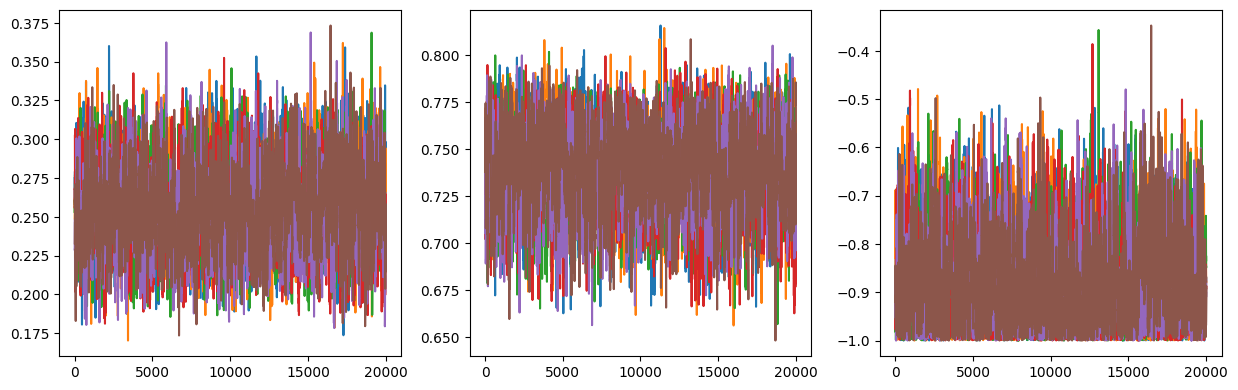

In [42]:
plt.figure(figsize=(15,4.5))
plt.subplot(131)
for i in range(6):
    plt.plot(sampler3d.chain[i,n_burn3d:,0])
plt.subplot(132)
for i in range(6):
    plt.plot(sampler3d.chain[i,n_burn3d:,1])
plt.subplot(133)
for i in range(6):
    plt.plot(sampler3d.chain[i,n_burn3d:,2])

[ 0.22116686  0.6965266  -0.90577465]


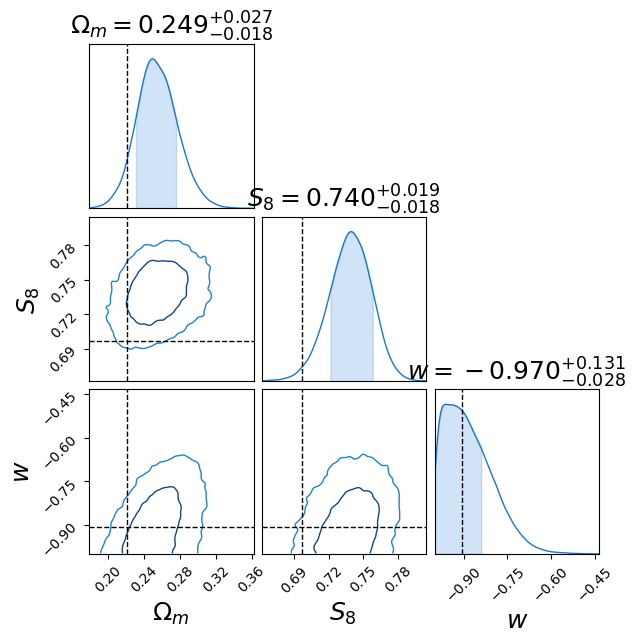

In [43]:
import emcee
from chainconsumer import ChainConsumer


samples3d = sampler3d.get_chain()

c = ChainConsumer()

c.add_chain([samples3d[n_burn3d:,:,0].flatten(),
             samples3d[n_burn3d:,:,1].flatten(),
             samples3d[n_burn3d:,:,2].flatten()],
            parameters=[r'$\Omega_m$', r'$S_8$', r'$w$'],linestyle = '-')

c.configure(sigmas = [1,2], label_font_size=18,
            shade = [False]*3,flip=False) 

fig = c.plotter.plot(truth=params_LFI[i_test], figsize=(6, 6),filename='./ccmc_prelim.pdf')

print(params_LFI[i_test])

[ 0.3124131   0.9412426  -0.70912766]
[ 0.38577685  0.6132572  -0.96508026]
[ 0.41288954  0.7866078  -0.5249864 ]
[ 0.32134122  0.6282001  -0.9930139 ]
[ 0.32386985  0.87184685 -0.9999999 ]
[ 0.20641246  0.6870955  -0.9630781 ]
[ 0.27942172  0.79848796 -0.9642796 ]
[ 0.35911137  0.64022964 -0.47055733]
[ 0.32919258  0.9106777  -0.36045504]
[ 0.31162834  0.8596163  -0.5708952 ]


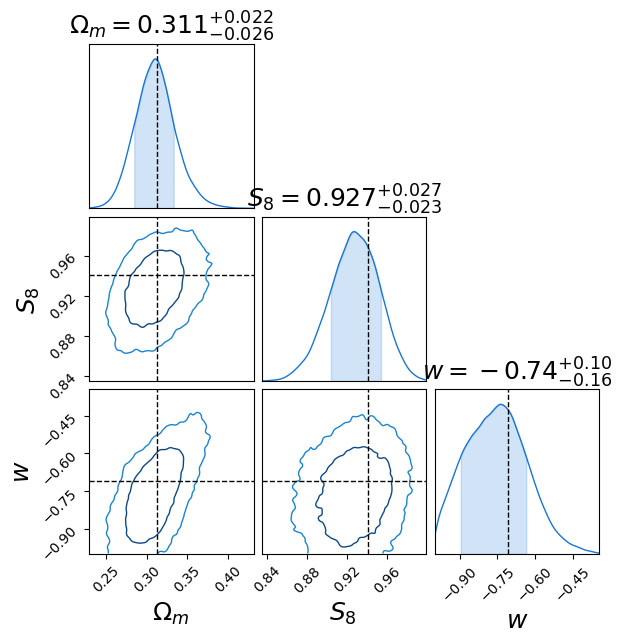

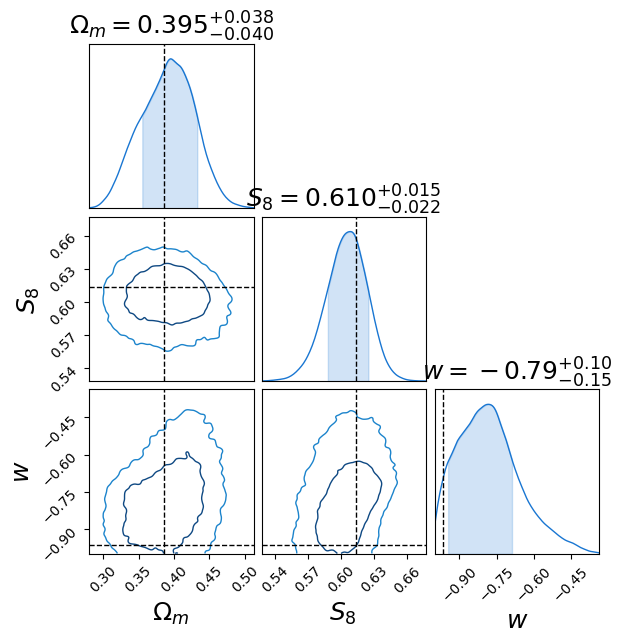

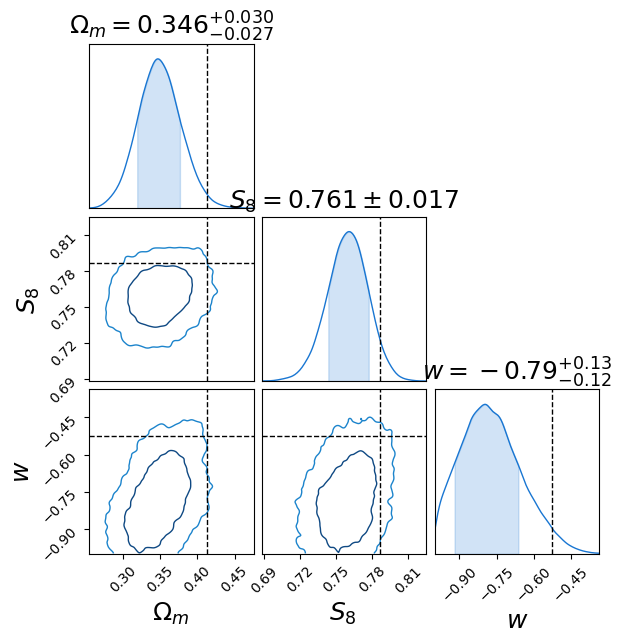

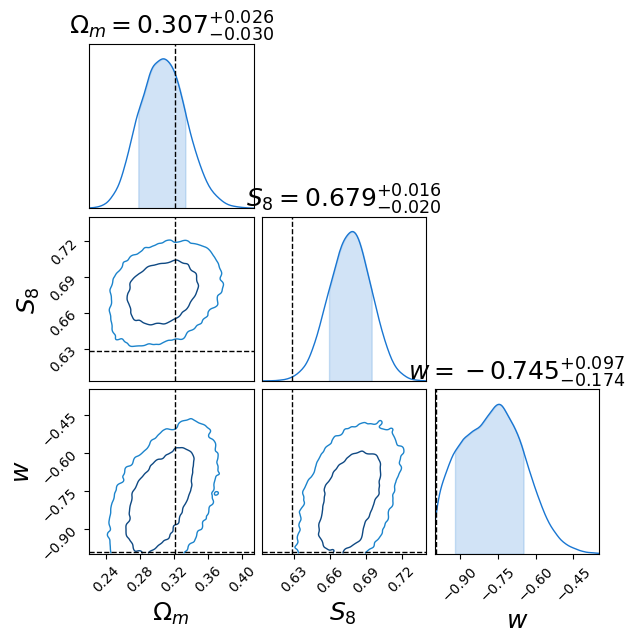

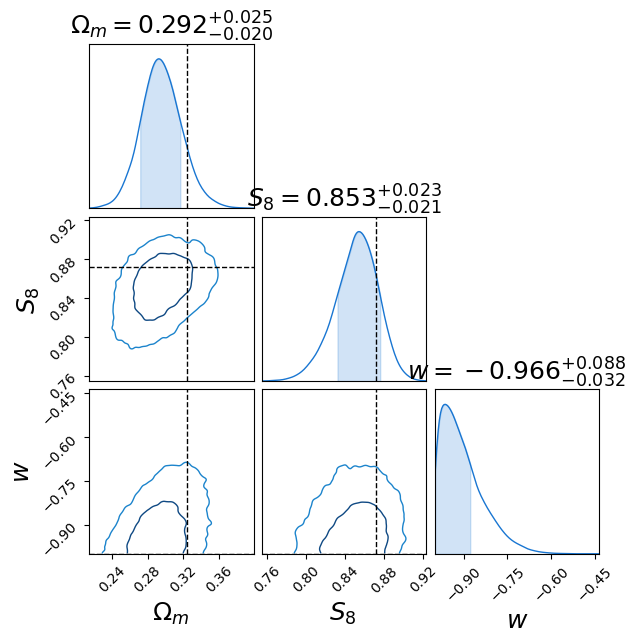

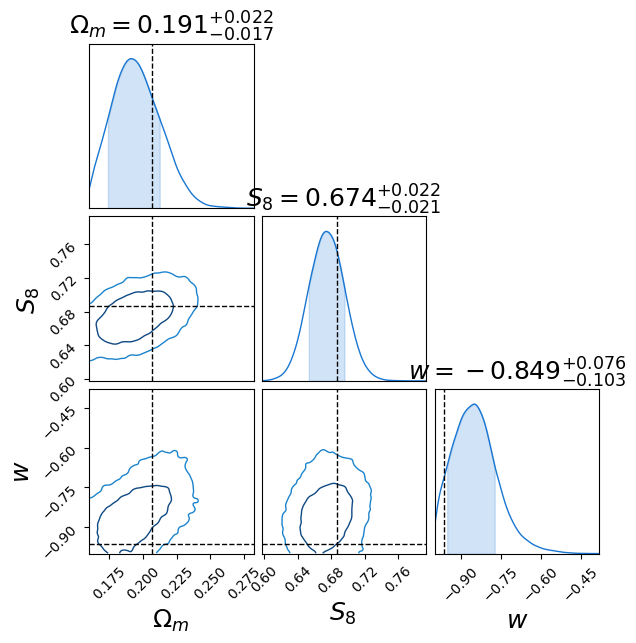

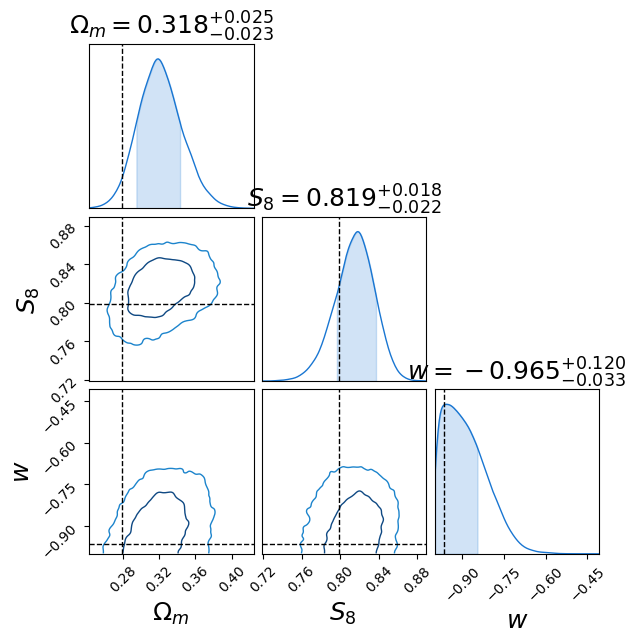

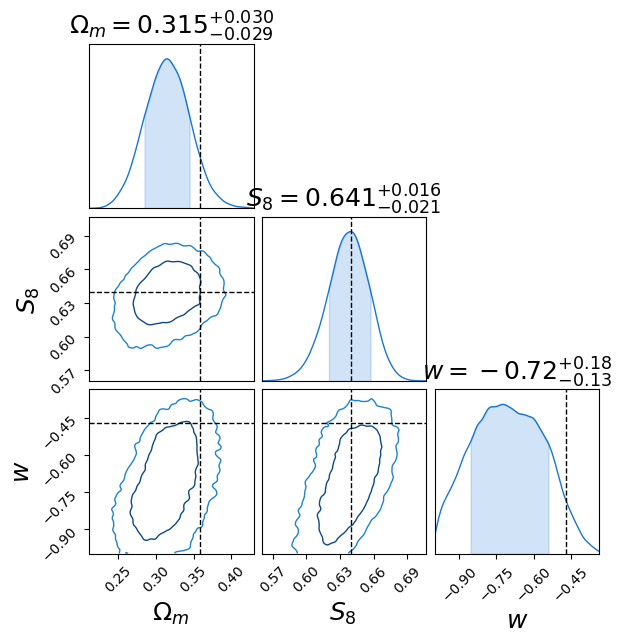

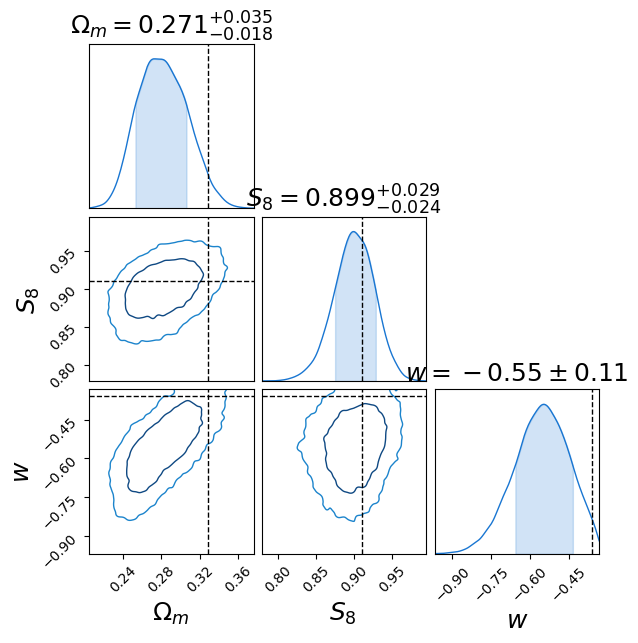

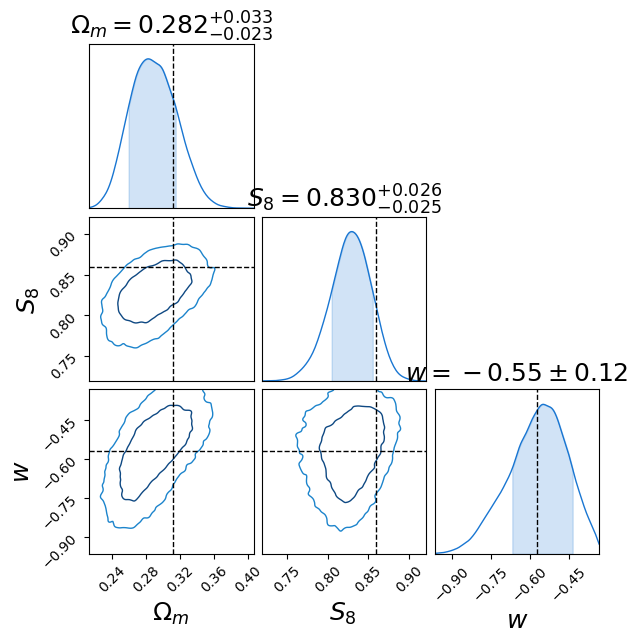

: 

In [ ]:
import emcee
from chainconsumer import ChainConsumer

for i in range(len(samples_LFI)):
    samples3d = samples_LFI[i]
    i_test = rand_inds[i]

    c = ChainConsumer()

    c.add_chain([samples3d[n_burn3d:,:,0].flatten(),
                samples3d[n_burn3d:,:,1].flatten(),
                samples3d[n_burn3d:,:,2].flatten()],
                parameters=[r'$\Omega_m$', r'$S_8$', r'$w$'],linestyle = '-')

    c.configure(sigmas = [1,2], label_font_size=18,
                shade = [False]*3,flip=False) 

    fig = c.plotter.plot(truth=params_LFI[i_test], figsize=(6, 6),filename='./ccmc_prelim.pdf')

    print(params_LFI[i_test])